# Finding my Circadian Rhythm in Spotify Listening History

## Data Cleaning and Filtering

In [40]:
# necessary imports

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from utils import filter_by_hour, findSkipRatio
import scipy.signal as signal
from scipy.stats import gaussian_kde

ImportError: cannot import name 'findSkipRatio' from 'utils' (c:\Users\User\GitRepos\Data-Analysis-on-Spotify-Streaming-History\utils.py)

In [3]:
fullHistory = pd.read_csv("Spotify Extended Streaming History/cleaned/cleaned-history.csv")
fullHistory['ts'] = pd.to_datetime(fullHistory['ts'])

In [4]:
hour00 = filter_by_hour(fullHistory, 0)
hour01 = filter_by_hour(fullHistory, 1)
hour02 = filter_by_hour(fullHistory, 2)
hour03 = filter_by_hour(fullHistory, 3)
hour04 = filter_by_hour(fullHistory, 4)
hour05 = filter_by_hour(fullHistory, 5)
hour06 = filter_by_hour(fullHistory, 6)
hour07 = filter_by_hour(fullHistory, 7)
hour08 = filter_by_hour(fullHistory, 8)
hour09 = filter_by_hour(fullHistory, 9)
hour10 = filter_by_hour(fullHistory, 10)
hour11 = filter_by_hour(fullHistory, 11)
hour12 = filter_by_hour(fullHistory, 12)
hour13 = filter_by_hour(fullHistory, 13)
hour14 = filter_by_hour(fullHistory, 14)
hour15 = filter_by_hour(fullHistory, 15)
hour16 = filter_by_hour(fullHistory, 16)
hour17 = filter_by_hour(fullHistory, 17)
hour18 = filter_by_hour(fullHistory, 18)
hour19 = filter_by_hour(fullHistory, 19)
hour20 = filter_by_hour(fullHistory, 20)
hour21 = filter_by_hour(fullHistory, 21)
hour22 = filter_by_hour(fullHistory, 22)
hour23 = filter_by_hour(fullHistory, 23)

In [38]:
# verifying filtering works correctly
hour00.sample(10)

,ts,ms_played,conn_country,master_metadata_track_name,master_metadata_album_artist_name,master_metadata_album_album_name,reason_start,reason_end,skipped
297743,2021-10-02 00:24:50+00:00,257200,GB,Lucy - 2010 Remastered Version,Nick Cave & The Bad Seeds,The Good Son,trackdone,trackdone,False
154967,2025-01-03 00:26:05+00:00,298826,GB,Risingson,Massive Attack,Mezzanine,trackdone,trackdone,False
309200,2021-11-27 00:26:52+00:00,175933,GB,Rain Dogs,Tom Waits,Rain Dogs,trackdone,trackdone,False
76824,2023-03-03 00:13:50+00:00,24400,GB,Never Again,slowthai,UGLY,trackdone,fwdbtn,True
20964,2022-01-24 00:18:18+00:00,2339,GB,You Know I'm No Good,Amy Winehouse,Back To Black,trackdone,fwdbtn,False
20985,2022-01-24 00:35:03+00:00,487,GB,All My Heroes Are Cornballs,JPEGMAFIA,All My Heroes Are Cornballs,backbtn,fwdbtn,False
113400,2024-01-14 00:47:05+00:00,160659,GB,striptease,carwash,striptease,trackdone,trackdone,False
26881,2022-03-05 00:45:31+00:00,86076,GB,The Haunting Presence,Giles Corey,Giles Corey,fwdbtn,unexpected-exit-while-paused,False
44471,2022-07-02 00:36:05+00:00,169856,GB,Can You Get To That,Funkadelic,Maggot Brain,trackdone,trackdone,False
106599,2023-11-15 00:49:28+00:00,245023,GB,I Don't Love Me Anymore,Oneohtrix Point Never,Magic Oneohtrix Point Never,fwdbtn,trackdone,False


## Finding The Underlying Schedule

In [6]:
hours = [hour00, hour01, hour02, hour03, hour04, hour05, hour06, hour07, hour08, hour09, hour10, hour11, hour12, hour13, hour14, hour15, hour16, hour17, hour18, hour19, hour20, hour21, hour22, hour23]

In [7]:
allTime = fullHistory['ms_played'].sum()
hourSplits = []
for hour in hours:
    hourTotal = hour['ms_played'].sum()
    ratio = round((hourTotal/allTime)*100, 2) 
    hourSplits.append(float(ratio))
    print(f"Hour {hour['ts'].dt.hour.iloc[0]}: {ratio}% of total listening time")

Hour 0: 4.25% of total listening time
Hour 1: 2.03% of total listening time
Hour 2: 1.09% of total listening time
Hour 3: 0.66% of total listening time
Hour 4: 0.48% of total listening time
Hour 5: 0.39% of total listening time
Hour 6: 1.04% of total listening time
Hour 7: 2.96% of total listening time
Hour 8: 3.94% of total listening time
Hour 9: 4.17% of total listening time
Hour 10: 4.92% of total listening time
Hour 11: 4.79% of total listening time
Hour 12: 4.28% of total listening time
Hour 13: 4.2% of total listening time
Hour 14: 5.28% of total listening time
Hour 15: 5.99% of total listening time
Hour 16: 6.85% of total listening time
Hour 17: 6.11% of total listening time
Hour 18: 5.31% of total listening time
Hour 19: 5.54% of total listening time
Hour 20: 5.89% of total listening time
Hour 21: 6.41% of total listening time
Hour 22: 7.05% of total listening time
Hour 23: 6.38% of total listening time


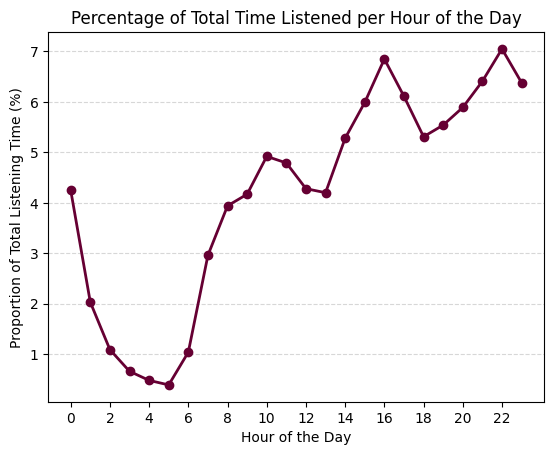

In [27]:
plt.plot(hourSplits, marker='o', ls='-', c='#660033', linewidth=2)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(range(0,24,2))
plt.title('Percentage of Total Time Listened per Hour of the Day')
plt.ylabel('Proportion of Total Listening Time (%)')
plt.xlabel('Hour of the Day')
plt.show()

Based on the raw numbers above, I can see a clear period of peak listening from 2pm to 11pm, with a non-negligible amount of tracks being listened to from 7am-1pm and in the midnight hour. However, I want to further analyse the timestamps and find out the distribution of my listening.

In [11]:
signal.find_peaks(hourSplits, height=0.5, distance=1)

(array([10, 16, 22]), {'peak_heights': array([4.92, 6.85, 7.05])})

The peaks in my data tell me that my primary listening sessions occur in the late morning, late afternoon and late evening. My instinctual guess is that this is because I will listen to music after breakfast whilst working, when I've come home from college/high school (I have had the account since year 6), and before I go to sleep. I'm going to perform a KDE on the data to try and verify the quickly calculated numbers above.

In [15]:
hourly_df = pd.DataFrame({'hour': range(24), 'time_played': hourSplits})
hours = hourly_df['hour']
hourly_df.head()

,hour,time_played
0,0,4.25
1,1,2.03
2,2,1.09
3,3,0.66
4,4,0.48


In [19]:
# padding the data to account for the circular nature of time (i.e. 23:00 is next to 00:00)
padded_hours = np.concatenate([hours-24, hours, hours+24])
padded_weights = np.concatenate([hourSplits, hourSplits, hourSplits])

In [35]:
kde = gaussian_kde(padded_hours, weights=padded_weights)
kde.set_bandwidth(bw_method=kde.factor*0.4) # adjusting bandwidth for smoother curve
x_grid = np.linspace(0, 24, 1000) # creating a grid of x values from 0 to 24
y_density = kde(x_grid) # evaluating the KDE on the grid
y_density = y_density/y_density.sum()*100 # normalizing the density to sum to 100 for percentage representation

In [36]:
peaks, _ = signal.find_peaks(y_density, distance=50, prominence=0.2) # finding peaks in the KDE density
peak_hours = x_grid[peaks] # getting the corresponding hours for the peaks
peak_densities = y_density[peaks] # getting the corresponding densities for the peaks

for h in peak_hours:
    hour_int = int(h)
    minute_int = int((h - hour_int) * 60)
    print(f"Peak at {hour_int:02d}:{minute_int:02d}")

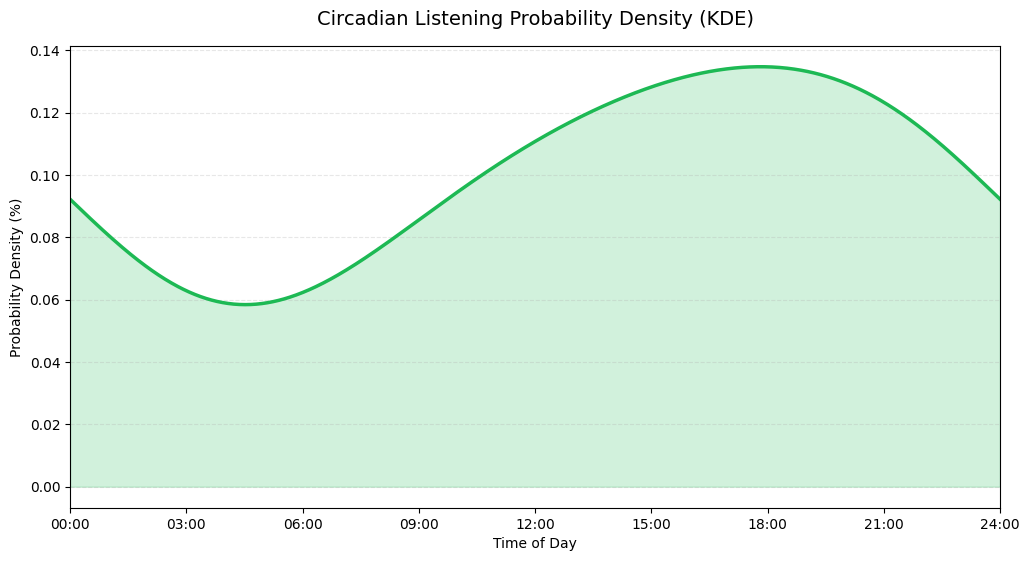

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot the smooth continuous KDE curve
ax.plot(x_grid, y_density, color='#1DB954', linewidth=2.5, label='KDE Density')

# Fill area under the curve for visual volume
ax.fill_between(x_grid, y_density, color='#1DB954', alpha=0.2)

# Styling adjustments
ax.set_xlim(0, 24)
ax.set_xticks(range(0, 25, 3))
ax.set_xticklabels([f"{h:02d}:00" for h in range(0, 25, 3)])
ax.set_title("Circadian Listening Probability Density (KDE)", fontsize=14, pad=15)
ax.set_xlabel("Time of Day")
ax.set_ylabel("Probability Density (%)")
ax.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

Here, the general shape of the graph at a larger scale matches the previous one made from my rougher calculations. There is a clear trough from midnight to about 8am, a peak around 4-6pm and a decline as the night goes on. However, the smoothing from the KDE shows clearly that the primary peak is at **16:00**, rather than at 22:00 and 10:00 also as the previous graph suggested. 

## Using Metadata to Determine Listening Habits in Specific Hours

In this section I will use the data of the tracks within the table to try and determine my listening profile. Specifically I will work out the ratio of tracks I skipped and the average length of an average song at these times (discounting skipped songs to avoid skewing) 

In [ ]:
def get_fwdbtn_ratio(df):
    """
    Calculate the ratio of tracks with reason_end == 'fwdbtn' in a dataframe.
    
    Args:
        df: pandas DataFrame containing listening history
        
    Returns:
        float: Ratio of tracks with reason_end == 'fwdbtn' (0.0 to 1.0)
    """
    fwdbtn_count = (df['reason_end'] == 'fwdbtn').sum()
    total_count = len(df)
    return fwdbtn_count / total_count if total_count > 0 else 0.0

## Measuring Diversity in Listening at Certain Hours

I'm going to calculate the Shannon Entropy for each of my hours listened to determine how diversified my listening is at different hours of the day.